## Imports

We take 5 days of data to build our trainingsdataset. To boost the efficiency, we resample only every 10th entry to get 144 entries for each queue for each day. That means we get our datapoints every 10 minutes. Afterwards

In [1]:
from elasticsearch import Elasticsearch
import pandas as pd
import numpy as np
import datetime
import keras
import pickle
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model
import time

Using TensorFlow backend.


In [2]:
# ignore 400 cause by IndexAlreadyExistsException when creating an index
es = Elasticsearch()
# es = Elasticsearch(
#       ['localhost'],
#       http_auth=(username, 'password'),
#       verify_certs=False,
#       scheme="https",
#       port=443,
# )
es.indices.create(index='queues-prediction', ignore=400) #can be ignored

{'error': {'root_cause': [{'type': 'resource_already_exists_exception',
    'reason': 'index [queues-prediction/2wrTfFGTS8COuco3Ewm92Q] already exists',
    'index_uuid': '2wrTfFGTS8COuco3Ewm92Q',
    'index': 'queues-prediction'}],
  'type': 'resource_already_exists_exception',
  'reason': 'index [queues-prediction/2wrTfFGTS8COuco3Ewm92Q] already exists',
  'index_uuid': '2wrTfFGTS8COuco3Ewm92Q',
  'index': 'queues-prediction'},
 'status': 400}

In [3]:
def es_timerange(start, end, rate, tier):
    """"
    a function that returns data from ES based on the time period
    and also transforms and resamples the data to further work with
    
    start : startdate in format "yyyy-MM-dd"
    end : enddate in format "yyyy-MM-dd"
    
    example:
    es_timerange("2020-06-01","2020-06-10")
    """
    slist = start.split("-")
    slist = map(int, slist)
    slist = list(slist)

    elist = end.split("-")
    elist = map(int, elist)
    elist = list(elist)

    sdate = datetime.date(slist[0],slist[1],slist[2])
    edate = datetime.date(elist[0],elist[1],elist[2])

    delta = edate - sdate
    
    datelist = list()
    for i in range(delta.days + 1):
        day = sdate + datetime.timedelta(days=i)
        datelist.append(day)
    
    final_data = list()
    for date in datelist:
        res = es.search(index="queues", body={"query" : {
                                            "bool" : { 
                                              "must" : [
                                                {"match": {
                                                        "name" : "products"}},
                                                  {"match": {
                                                        "tier" : tier}},
                                                {"range": {
                                                        "timestamp":{
                                                            "gte": str(date),
                                                            "lte": str(date),
                                                            "format": "yyyy-MM-dd"
                                                      }
                                                    }
                                                  }
                                              ]
                                            }
                                          }
                                        }, size=1440) #define size
        daily_data = [elem['_source'] for elem in res['hits']['hits']]
        final_data.extend(daily_data)  
        
    df = pd.DataFrame(final_data)
    
    df = df.iloc[::rate,:].copy() #take every nth entry
    df.index = df["timestamp"]
    df.index = pd.to_datetime(df.index, format='%Y-%m-%dT%H:%M:%S.%f%z').sort_values()
    df.drop(columns=['timestamp', 'name'], inplace=True) #drop unnecassry columns
    df['items'] = [[str(x)] if len(str(x)) < 10 else str(x).split(" ") for x in df['items']] #convert items to list
    df['size'] = pd.to_numeric(df['size'])
    return df
    

We take 5 days of data containing the pic and censhare q, with a sample rate of 10

In [4]:
df_pic = es_timerange("2020-06-03","2020-06-07", 10, "pic")

In [5]:
df_cen = es_timerange("2020-06-03","2020-06-07", 10, "censhare")

We build MulitLabelBinarized DataFrames to get information about each item, when it´s in the queue

In [6]:
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
df_cen_mlb = pd.DataFrame(mlb.fit_transform(df_cen['items']),columns=mlb.classes_)
df_pic_mlb = pd.DataFrame(mlb.fit_transform(df_pic['items']),columns=mlb.classes_)

We add Features to enrich the data.. 
The number of different items compared to the datapoint before.

In [7]:
lists = df_pic['items'].tolist()
current = lists[0]
diff_sets = [[]]
diff_sets_rev = [[]]
for next_list in lists[1:]:
    diff_sets.append(sorted(set(current).difference(set(next_list))))
    diff_sets_rev.append(sorted(set(next_list).difference(set(current))))
    current = next_list
    
df_pic['diff_items'] = diff_sets
df_pic['diff_items_rev'] = diff_sets_rev
df_pic['n_removed_items'] = df_pic['diff_items'].apply(lambda x: len(x))
df_pic['n_added_items'] = df_pic['diff_items_rev'].apply(lambda x: len(x))

Building the Dataset

Number of items in pic queue

In [8]:
len(df_pic_mlb.columns)

23855

Number of items in cen queue

In [9]:
len(df_cen_mlb.columns)

2539

Number of items in both queues 

In [10]:
len(set(df_cen_mlb.columns)&set(df_pic_mlb.columns))

2074

Number of items only in censhare 

In [11]:
len(df_cen_mlb.columns) - len(set(df_cen_mlb.columns)&set(df_pic_mlb.columns))

465

Number of items left in the last timestamp

In [12]:
len(df_pic['items'][-1])

1

In [13]:
len(df_pic['items'][0])

13620

Total items in dataset

In [14]:
len(df_pic_mlb.columns) - len(df_pic['items'][-1]) - len(df_pic['items'][0])

10234

We need to exclude items, that havent left the queue to get a clean dataset,

In [15]:
sizes_pic = df_pic['size'].values
added_pic = df_pic['n_added_items'].values
removed_pic = df_pic['n_removed_items'].values
df_pic_cumsum = df_pic_mlb.cumsum()
df_pic_cumsum_rev = df_pic_mlb.iloc[::-1].cumsum().iloc[::-1]
exclude_first = df_pic['items'][0]
exclude_last = df_pic['items'][-1]


data_x = list()
data_y = list()


for item in df_cen_mlb.columns:
    if ((item in df_pic_mlb.columns) and (item not in exclude_first and item not in exclude_last)):
    
        mask_cen = df_cen_mlb[item] != 0
        mask_pic = df_pic_mlb[item] != 0
        
        position_cen = df_cen_mlb[item][mask_cen].index[0]
        position_pic = df_pic_mlb[item][mask_pic].index[-1]
        position_pic_first = df_pic_mlb[item][mask_pic].index[0]
        
        
        if position_cen > position_pic:
            diff = position_pic - position_pic_first
            size = sizes_pic[position_pic_first:position_pic]
            added = added_pic[position_pic_first:position_pic]
            removed = removed_pic[position_pic_first:position_pic]
        else:
            diff = position_pic - position_cen
            size = sizes_pic[position_cen:position_pic]
            added = added_pic[position_cen:position_pic]
            removed = removed_pic[position_cen:position_pic]
            
            
        
        steps_list = list(range(1,diff+1))
        
        
        df_item = pd.DataFrame(data=steps_list, columns=['n_steps_in_Q']).astype(str).astype(int)
        
        df_item['Q_size'] = size
        df_item['n_added'] = added
        df_item['n_removed'] = removed
        df_item['cen'] = 1
        
        y_item = pd.DataFrame(data=steps_list[::-1], columns=[item])
        mask_2 = y_item[item] != 0
        #y_item = np.array(steps_list)
        y_item2 = y_item[item][mask_2]
        data_x.append(df_item)
        data_y.append(y_item2)
        
    
    else:
        continue
        """mask_cen = df_cen_mlb[item] != 0
              
        position_cen = df_cen_mlb[item][mask_cen].index[0]
        
        diff = len(df_cen_mlb) - position_cen        
        
        size = sizes_pic[position_cen:]
        added = added_pic[position_cen:]
        removed = removed_pic[position_cen:]
        
        steps_list = list(range(1,diff+1))
        
        df_item = pd.DataFrame(data=steps_list, columns=['n_steps_in_Q'])
        df_item['Q_size'] = size
        df_item['n_added'] = added
        df_item['n_removed'] = removed
        #df_item['cen'] = 1
        
        y_item = pd.DataFrame(data=steps_list[::-1], columns=[item])

        data_x.append(df_item)
        data_y.append(y_item)"""
        

for item in df_pic_mlb.columns:
    if ((item not in df_cen_mlb.columns) and (item not in exclude_first and item not in exclude_last)):
        mask = df_pic_mlb[item] != 0
        
        X_item = pd.DataFrame(df_pic_cumsum[item][mask])
        X_item = X_item.rename(columns = {item: 'n_steps_in_Q'})
        X_item['Q_size'] = sizes_pic[mask]
        X_item['n_added'] = added_pic[mask]
        X_item['n_removed'] = removed_pic[mask]
        X_item['cen'] = 0
        
        y_item = df_pic_cumsum_rev[item][mask]
        
        data_x.append(X_item)
        data_y.append(y_item)  
    else:
        continue

In [16]:
len(data_x)

10235

In [17]:
data_x[0]

,n_steps_in_Q,Q_size,n_added,n_removed,cen
0,1,13620,0,0,1
1,2,13640,23,3,1
2,3,13603,236,273,1
3,4,13595,87,95,1
4,5,13614,52,33,1
...,...,...,...,...,...
426,427,0,0,0,1
427,428,0,0,0,1
428,429,0,0,0,1
429,430,9,9,1,1


In [18]:
data_y[0]

0      431
1      430
2      429
3      428
4      427
      ... 
426      5
427      4
428      3
429      2
430      1
Name: 1000928402, Length: 431, dtype: int64

## Pickle DS Save/Load

In [19]:
import pickle
pickle.dump(data_x, open("X_cen_pic_4.p","wb"))
pickle.dump(data_y, open("y_cen_pic_4.p","wb"))

In [20]:
X = pickle.load(open("X_cen_pic_4.p", "rb"))
y = pickle.load(open("y_cen_pic_4.p", "rb"))

### Train Test Split/Padding

In [27]:
maxlen = len(df_pic)

In [76]:
maxlen

720

In [28]:
from keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
def pad(sequence, maxlen):
    # fills list post (at the end) with 0s to make even sized sequences
    return pad_sequences(sequence, maxlen=maxlen, dtype='float32', padding='post', value=0.0)

In [29]:
def split_train_test_seq(X, y, **kwargs):
    """ Splits the datasets, after padding the sequences
    to a global length
    
    Parameters:
    X : preprocessed datasets including features
    y : preprocessd datasets with target variable
    
    Returns:
    X_train : feature sequences padded with 0 in shape (number of samples, timesteps, features)
    X_test : feature sequences padded with 0 in shape (number of samples, timesteps, features)
    y_train : target sequences padded with 0 in shape (number of samples, timesteps, features)
    y_test : target sequences padded with 0 in shape (number of samples, timesteps, features)
    """
    # maxlen for padding
    #maxlen = max(len(x) for x in y)
    
    #train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, **kwargs)
    
    #padding 
    X_train = pad([x.values for x in X_train], maxlen)
    X_test = pad([x.values for x in X_test], maxlen)

    #reshape for LSTM
    y_train = pad([y.values for y in y_train], maxlen)
    y_train = [x.reshape(-1,1) for x in y_train]
    y_train = np.asarray(y_train)
    
    y_test = pad([y.values for y in y_test], maxlen)
    y_test = [x.reshape(-1,1) for x in y_test]
    y_test = np.asarray(y_test)
    
    
    # for validation 
    # 0.7 * 0.2 (20% validation data from train)
    # X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.14)
    # X_val = pad([x.values for x in X_val], maxlen)
    # y_val = pad([y.values for y in y_val], maxlen)
    # y_val = [x.reshape(-1,1) for x in y_val]
    # y_val = np.asarray(y_val)
    
    
    #for train_on_batch
    #X_train = [x.reshape(1,-1,5) for x in X_train]
    #X_train = np.asarray(X_train)
    #X_test = [x.reshape(1,-1,5) for x in X_test]
    #X_test = np.asarray(X_test)
    #X_val = [x.reshape(1,-1,5) for x in X_val]
    #X_val = np.asarray(X_val)
    #, X_val, y_val
    #, X_valseq, y_valseq
    #X_valseq.shape, y_valseq.shape
    return X_train, X_test, y_train, y_test

In [30]:
X_trainseq, X_testseq, y_trainseq, y_testseq = split_train_test_seq(X, y, test_size=0.3)

### Feature Scaling

In [31]:
from sklearn.preprocessing import StandardScaler

In [32]:
n_tr, ts, d_X = X_trainseq.shape # n = number of samples, ts = number of Timesteps, d = dimension of input(Features)
n_te, ts, _ = X_testseq.shape
d_y = 1
scaler_X = StandardScaler()
X_trainseq = scaler_X.fit_transform(X_trainseq.reshape(n_tr*ts, d_X)).reshape(X_trainseq.shape)
X_testseq = scaler_X.transform(X_testseq.reshape(n_te*ts, d_X)).reshape(X_testseq.shape)
scaler_y = StandardScaler()
y_trainseq = scaler_y.fit_transform(y_trainseq.reshape(n_tr*ts, d_y)).reshape(y_trainseq.shape)
y_testseq = scaler_y.transform(y_testseq.reshape(n_te*ts, d_y)).reshape(y_testseq.shape)

## Save Pickle transformed 

In [33]:
pickle.dump(scaler_X, open("res_scaler_X_cen_pic.p","wb"))
pickle.dump(scaler_y, open("res_scaler_y_cen_pic.p","wb"))

In [34]:
pickle.dump(X_trainseq, open("res_X_trainseq_cen_pic.p","wb"))
pickle.dump(X_testseq, open("res_X_testseq_cen_pic.p","wb"))
pickle.dump(y_trainseq, open("res_y_trainseq_cen_pic.p","wb"))
pickle.dump(y_testseq, open("res_y_testseq_cen_pic.p","wb"))

## Load Pickle transformed

In [35]:
import pickle

In [36]:
X_trainseq = pickle.load(open("res_X_trainseq_cen_pic.p", "rb"))
y_trainseq = pickle.load(open("res_y_trainseq_cen_pic.p", "rb"))
X_testseq = pickle.load(open("res_X_testseq_cen_pic.p", "rb"))
y_testseq = pickle.load(open("res_y_testseq_cen_pic.p", "rb"))

In [37]:
scaler_X = pickle.load(open("res_scaler_X_cen_pic.p", "rb"))
scaler_y = pickle.load(open("res_scaler_y_cen_pic.p", "rb"))

### Downsampling

In [38]:
mask_train = np.random.choice([False, True], len(X_trainseq), p=[0.5,0.5])
mask_test = np.random.choice([False, True], len(X_testseq), p=[0.5,0.5])

X_train_sampled = X_trainseq[mask_train]
y_train_sampled = y_trainseq[mask_train]

X_test_sampled = X_testseq[mask_test]
y_test_sampled = y_testseq[mask_test]

## LSTM

In [39]:
from keras.models import Sequential
from keras.layers import Dense, Masking, GRU, LSTM, Dropout

In [40]:
ts = X_train_sampled.shape[1]
d_X = X_train_sampled.shape[2]

In [41]:
n_steps = ts #576
n_features = d_X #5
n_neurons = 20

In [42]:
model = Sequential()
model.add(Masking(mask_value=0.0,input_shape=(n_steps, n_features))) #Masking Layer for padding 
model.add(LSTM(n_neurons, return_sequences=True))
model.add(Dropout(0.1))
model.add(LSTM(n_neurons, return_sequences=True))
model.add(Dense(1, input_dim=n_neurons)) #Dense Layer to generate 1Dimensional Outputs
model.compile(loss='mae', optimizer='adam', metrics=['mae'])
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
masking_1 (Masking)          (None, 720, 5)            0         
_________________________________________________________________
lstm_1 (LSTM)                (None, 720, 20)           2080      
_________________________________________________________________
dropout_1 (Dropout)          (None, 720, 20)           0         
_________________________________________________________________
lstm_2 (LSTM)                (None, 720, 20)           3280      
_________________________________________________________________
dense_1 (Dense)              (None, 720, 1)            21        
Total params: 5,381
Trainable params: 5,381
Non-trainable params: 0
_________________________________________________________________


### Callbacks

In [43]:
from keras.callbacks import EarlyStopping

In [44]:
early_stop = EarlyStopping(monitor='mae', mode='min', patience=5)

In [45]:
history = model.fit(X_train_sampled, y_train_sampled, epochs=5, validation_split=0.2, callbacks=[early_stop])

Train on 2866 samples, validate on 717 samples
Epoch 1/5
2866/2866 [==============================] - 202s 71ms/step - loss: 0.1705 - mae: 0.1705 - val_loss: 0.1124 - val_mae: 0.1124
Epoch 2/5
2866/2866 [==============================] - 201s 70ms/step - loss: 0.1206 - mae: 0.1206 - val_loss: 0.1065 - val_mae: 0.1065
Epoch 3/5
2866/2866 [==============================] - 201s 70ms/step - loss: 0.1124 - mae: 0.1124 - val_loss: 0.0992 - val_mae: 0.0992
Epoch 4/5
2866/2866 [==============================] - 202s 70ms/step - loss: 0.1057 - mae: 0.1057 - val_loss: 0.0989 - val_mae: 0.0989
Epoch 5/5
2866/2866 [==============================] - 201s 70ms/step - loss: 0.1061 - mae: 0.1061 - val_loss: 0.0975 - val_mae: 0.0975


## Save Model

In [46]:
model.save("res_model_items_pic_cen.h5")

## Load Model

In [47]:
from tensorflow.keras.models import load_model

In [48]:
model = load_model("res_model_items_pic_cen.h5")

### Predictions and Rescaling

In [49]:
pred = model.predict(X_test_sampled)
y_pred = scaler_y.inverse_transform(pred.reshape(-1, 1)).reshape(pred.shape)
y_testresc = scaler_y.inverse_transform(y_test_sampled.reshape(-1, 1)).reshape(y_test_sampled.shape)
n_te = X_test_sampled.shape[0]
X_testresc = scaler_X.inverse_transform(X_test_sampled.reshape(n_te*ts, 5)).reshape(X_test_sampled.shape)

### Plots

In [50]:
import matplotlib.pyplot as plt

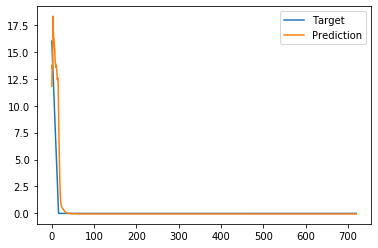

<Figure size 432x288 with 0 Axes>

In [75]:
x = np.random.randint(len(y_test_sampled))
plt.plot(y_testresc[x], label='Target')
plt.plot(y_pred[x], label='Prediction')
plt.legend()
plt.show()
plt.savefig('foo.png')

## Score

Masking all entries that aren´t zero (<= 1e-4) to leave out the padded values 

In [52]:
mask = ~np.all((X_testresc.reshape(-1, d_X) <= 1e-4) & (X_testresc.reshape(-1, d_X) >= -1e-4), axis=-1)

In [53]:
from sklearn.metrics import mean_absolute_error

In [54]:
mean_absolute_error(y_testresc.reshape(-1)[mask], y_pred.reshape(-1)[mask])

55.03761

In [55]:
25.286 * 10 /60

4.214333333333333